In [1]:
import os
import gc
import sys

import tensorflow as tf

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../")))

from srlib.deep_learning.esrgan import ESRGAN
from srlib.dataset.loading import load_esrgan_dataset
from srlib.dataset.visualization import plot_patch_pairs
from srlib.constants import (
    CLASS_LABELS_PATH,
    ESRGAN_BATCH_SIZE,
    ESRGAN_GROWTH_CHANNELS,
    ESRGAN_PATCH_SIZE,
    ESRGAN_RRDB_BLOCKS,
    ESRGAN_SCALE_FACTOR,
    ESRGAN_STRIDE,
    HR_ROOT,
    LR_ROOT,
)

c:\Users\bgmanuel\anaconda3\envs\py310\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\bgmanuel\anaconda3\envs\py310\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.10.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.

In [2]:
# Enable memory growth (prevents full pre-allocation)
for gpu in tf.config.experimental.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print(f"Memory growth not set: {e}")

In [3]:
X_train, Y_train, X_val, Y_val, X_test, Y_test = load_esrgan_dataset(
    HR_ROOT,
    LR_ROOT,
    CLASS_LABELS_PATH,
    patch_size=ESRGAN_PATCH_SIZE,
    stride=ESRGAN_STRIDE,
    scale_factor=ESRGAN_SCALE_FACTOR,
)


 ESRGAN dataset | patch 24, stride 24, x2
  images    798 indexed -> 798 kept -> 574 train / 64 val / 160 test


  patches   57,400 train / 6,400 val / 16,000 test   of 24 x 24 x 3
  memory    1.99 GB
  range     X [0.0000, 1.0000]   Y [0.0000, 1.0000]
  done in 9.9s



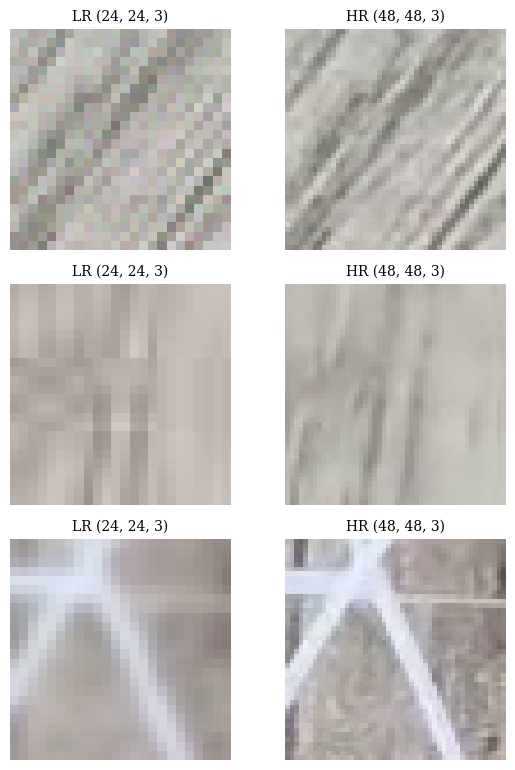

In [4]:
# What the model is actually fed: the LR patch and the HR patch it must
# reconstruct, whose side is ESRGAN_SCALE_FACTOR times larger.
_ = plot_patch_pairs(X_train, Y_train, count=3, seed=0)

In [5]:
# The test dataset is also defined here (only for later evaluation)
# Normalised to [-1,1] to match what training used
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, Y_test)).batch(ESRGAN_BATCH_SIZE)
test_dataset = test_dataset.map(lambda x,y: (x*2.0 - 1.0, y*2.0 - 1.0), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

In [6]:
model = ESRGAN()

model.setup_model(
    scale_factor=ESRGAN_SCALE_FACTOR, 
    growth_channels=ESRGAN_GROWTH_CHANNELS, 
    num_rrdb_blocks=ESRGAN_RRDB_BLOCKS, 
    input_shape=X_train.shape[1:],
    output_shape=Y_train.shape[1:],
    from_trained=False
)

GENERATOR SUMMARY
Model: "Generator"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 lr_input (InputLayer)          [(None, 24, 24, 3)]  0           []                               
                                                                                                  
 initial_conv (Conv2D)          (None, 24, 24, 64)   1792        ['lr_input[0][0]']               
                                                                                                  
 rrdb_0_dense1_conv1 (Conv2D)   (None, 24, 24, 16)   9232        ['initial_conv[0][0]']           
                                                                                                  
 rrdb_0_dense1_concat1 (Concate  (None, 24, 24, 80)  0           ['initial_conv[0][0]',           
 nate)                                                            'rrdb_

In [7]:
# Train ESRGAN and capture callbacks for metrics. The preview grids are
# staged outside the run directory and moved into it when the model is
# saved, so an interrupted run does not leave an incomplete run behind.
epoch_losses, time_cb, mem_cb = model.fit(
    X_train=X_train, 
    Y_train=Y_train, 
    X_val=X_val, 
    Y_val=Y_val,
    epochs=50, 
    batch_size=ESRGAN_BATCH_SIZE,
)

Training on GPU: ['/physical_device:GPU:0']
- LR schedule: x0.5 every 44850 steps, 4 times over 179400 steps
Epoch 1/50
  Step 10/3588 G_loss=0.2314 D_loss=1.3863 PSNR=19.60 SSIM=0.2540
  Step 20/3588 G_loss=0.2284 D_loss=1.3863 PSNR=20.73 SSIM=0.4200
  Step 30/3588 G_loss=0.1928 D_loss=1.3863 PSNR=22.53 SSIM=0.5183
  Step 40/3588 G_loss=0.1530 D_loss=1.3863 PSNR=24.27 SSIM=0.6132
  Step 50/3588 G_loss=0.1541 D_loss=1.3862 PSNR=24.35 SSIM=0.6436
  Step 60/3588 G_loss=0.1495 D_loss=1.3863 PSNR=25.52 SSIM=0.7021
  Step 70/3588 G_loss=0.1246 D_loss=1.3863 PSNR=26.17 SSIM=0.6886
  Step 80/3588 G_loss=0.1436 D_loss=1.3862 PSNR=25.47 SSIM=0.6511
  Step 90/3588 G_loss=0.1260 D_loss=1.3862 PSNR=25.84 SSIM=0.6556
  Step 100/3588 G_loss=0.1252 D_loss=1.3862 PSNR=26.67 SSIM=0.7224
  Step 110/3588 G_loss=0.1442 D_loss=1.3860 PSNR=25.56 SSIM=0.7118
  Step 120/3588 G_loss=0.1234 D_loss=1.3858 PSNR=26.29 SSIM=0.7148
  Step 130/3588 G_loss=0.1014 D_loss=1.3858 PSNR=28.67 SSIM=0.7216
  Step 140/3588 G_

In [8]:
del X_train, Y_train, X_val, Y_val  # Free memory
gc.collect()  # Force garbage collection to free memory

324

In [9]:
# Evaluates the run, saves generator and discriminator, the metrics and the
# staged preview grids, all under one timestamp.
timestamp, run_dir, metrics = model.evaluate_and_save(
    test_dataset, epoch_losses, time_cb, mem_cb,
)


 ESRGAN run 20260915_175433
  evaluating on the test partition
Evaluating model on test dataset...
Evaluation Results:
  Average PSNR: 28.9826
  Average SSIM: 0.7619
  Average G Loss: 0.0988
Generator model saved to c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\ESRGAN\ESRGAN_20260915_175433\ESRGAN_generator_x2_20260915_175433.h5
Discriminator model saved to c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\ESRGAN\ESRGAN_20260915_175433\ESRGAN_discriminator_x2_20260915_175433.h5
  metrics    -> c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\ESRGAN\ESRGAN_20260915_175433\ESRGAN_20260915_175433_metrics.pkl
  summary    -> c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\ESRGAN\ESRGAN_20260